In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pynhd
import py3dep
from pynhd import NLDI
import rioxarray
import rasterio as rio
import geopandas as gpd

#%matplotlib widget


In [2]:
class Vector:
    def __init__(self, vector):
        if vector.size not in [2,3]:
            raise ValueError("Array of length 2 or 3 expected, got length of {0}".format(len(vector)))
        self.dim = vector.size
        self.v = vector
        self.mag = np.sqrt(vector.dot(vector))
        self.x = vector[0]
        self.y = vector[1]
        if self.dim == 3:
            self.z = vector[2]
            self.alpha = np.arccos(self.x / self.mag)
            self.beta = np.arccos(self.y / self.mag)
            self.zenith = np.arccos(self.z / self.mag)
            # This returns I think the right value? Does not seem to work after 270 deg...then returns a negative number, appears to be with arctan2 function
            self.azimuth = (np.pi/2) + np.arctan2(self.y, self.x)
        else:
            self.azimuth = (np.pi/2) + np.arctan2(self.y, self.x)

    def is_unit(self):
        if self.mag == 1:
            return True
        else:
            return False

def sunpos(sv):
    azimuth = np.degrees(np.pi - np.arctan2(sv[0],sv[1]))
    zenith = np.degrees(np.arccos(sv[2]))
    return(np.array([azimuth, zenith]))

def normalvector(sp):
    rads = np.radians(sp)
    nvx = np.sin(rads[0]) * np.sin(rads[1])
    nvy = -np.cos(rads[0])*np.sin(rads[1])
    nvz = np.cos(rads[1])
    return(np.array([nvx, nvy, nvz]))

def inv_sun_angles(sp):
    inv_az = (sp[0] + 180) % 360
    inv_zen = 90 - sp[1]
    return(np.array([inv_az, inv_zen]))

def pyramid(n):
    r = np.arange(n)
    d = np.minimum(r,r[::-1])
    return np.minimum.outer(d,d)

def doshade(dem, sv, res):
    sunvector = sv  # from sunvector R function
    dl = res
    sunvector = Vector(sunvector)
    sombra = np.ones(dem.shape)
    vectororigin = np.zeros(3)
    nrows = dem.shape[0]
    ncols = dem.shape[1]

    #zint = np.zeros(dem.shape)
    #x_int = np.zeros(dem.shape)
    #y_int = np.zeros(dem.shape)
    #zproj = np.zeros(dem.shape)

    inversesunvector = Vector(-sunvector.v / np.max(np.abs([sunvector.x, sunvector.y])))

    sp = sunpos(sunvector.v)
    inv_sp = inv_sun_angles(sp)
    normalsunvector = Vector(normalvector(inv_sp))

    casx = int(1e6 * sunvector.x)
    casy = int(1e6 * sunvector.y)
    if casx < 0:
        f_i = 0
    else:
        f_i = ncols - 1

    if casy < 0:
        f_j = 0
    else:
        f_j = nrows - 1

    j = f_j
    #print("Doing columns")
    for i in range(ncols):
        n = 0
        zcompare = -1e13
        while n >= 0:
            dx = inversesunvector.x * n
            dy = inversesunvector.y * n
            idx = int(i + dx)
            jdy = int(j + dy)
            if ((idx < 0) | (idx > ncols-1)) | ((jdy < 0) | (jdy > nrows-1)):
                #print("i While break at n={0}".format(n))
                break
            vectororigin[0] = dx * dl
            vectororigin[1] = dy * dl
            vectororigin[2] = dem[jdy, idx]
            zprojection = np.dot(vectororigin, normalsunvector.v)
            #x_int[jdy, idx] = vectororigin[0]
            #y_int[jdy, idx] = vectororigin[1]
            #zint[jdy, idx] = vectororigin[2]
            #zproj[jdy, idx] = zprojection
            if zprojection < zcompare:
                sombra[jdy, idx] = 0
            else:
                zcompare = zprojection
            
            n = n + 1

    i = f_i
    #print("Doing rows")
    for j in range(nrows):
        n = 0
        zcompare = -1e13
        while n >= 0:
            dx = inversesunvector.x * n
            dy = inversesunvector.y * n
            idx = int(i + dx)
            jdy = int(j + dy)
            if ((idx < 0) | (idx > ncols-1)) | ((jdy < 0) | (jdy > nrows-1)):
                #print("j While break at n={0}".format(n))
                break
            vectororigin[0] = dx * dl
            vectororigin[1] = dy * dl
            vectororigin[2] = dem[jdy, idx]
            zprojection = np.dot(vectororigin, normalsunvector.v)
            #x_int[jdy, idx] = vectororigin[0]
            #y_int[jdy, idx] = vectororigin[1]
            #zint[jdy, idx] = vectororigin[2]
            #zproj[jdy, idx] = zprojection
            if zprojection < zcompare:
                sombra[jdy, idx] = 0
            else:
                zcompare = zprojection
            
            n = n + 1
    
    return sombra


def cgrad(dem, dlx, cArea=False):
    
    dly = dlx
    grad = np.gradient(dem)
    x_grad = grad[0] * 0.5 * dlx
    y_grad = grad[1] * 0.5 * dly
    z_grad = np.ones(dem.shape)
    z_grad = z_grad * dlx * dly
    cellArea = np.sqrt(x_grad**2 + y_grad**2 + z_grad**2)
    cellgr = np.stack([x_grad, y_grad, z_grad], axis=2)
    if cArea:
        return cellArea 
    else:
        for i in np.arange(3):
            cellgr[:,:,i] = cellgr[:,:,i] / cellArea
        
        return cellgr


def hillshading(cgrad, sv):
    hsh = cgrad[:,:,0] * sv[0] + cgrad[:,:,1] * sv[1] + cgrad[:,:,2] * sv[2]
    hsh = (hsh + np.abs(hsh)) / 2
    return hsh

def doshade_geometry(raster, geom, sun_vector, poly_output='scalar'):
    # raster is a rioxarray DataArray or Dataset of elevation
    # assumes raster and geom are in the same crs
    # geom is a geopandas.GeoDataFrame
    g = geom.geometry.iloc[0]
    datarray = raster.data
    transform = raster.rio.transform()
    data_res = raster.rio.resolution()[0]
    
    xv = sun_vector[0]
    yv = sun_vector[1]
    zv = sun_vector[2]
    nrows, ncols = datarray.shape
    ray_ln = np.max(datarray.shape)
    d = np.sqrt(np.sqrt(1)/(xv**2 + yv**2))
    dr = np.arange(0, ray_ln, d)
    xr = (dr * xv).astype(int)
    yr = (dr * yv).astype(int)
    zr = dr * data_res * zv
    
    if g.geom_type == 'Point':
        origin = rio.transform.rowcol(transform, g.x, g.y)
        zorigin = datarray[origin[0], origin[1]]
        xis = xr + origin[1]
        yjs = yr + origin[0]
        zproj = zr + zorigin
        lnmsk = np.where(((xis > 0) & (xis < ncols-1)) & ((yjs > 0) & (yjs < nrows-1)))
        xi_clp = xis[lnmsk[0]]
        yj_clp = yjs[lnmsk[0]]
        z_ext = datarray[yj_clp, xi_clp]

        zdiff = zproj[lnmsk[0]] - z_ext
    
        if (zdiff < 0).any():
            shd = 0.0
        else:
            shd = 1.0

    elif g.geom_type == 'Polygon':
        clipped = raster.rio.clip(geom.geometry.values, geom.crs, drop=False)
        origins = np.where(~np.isnan(clipped))
        zorigins = datarray[origins[0], origins[1]]
        xos = origins[1][None, :]
        yos = origins[0][None, :]
        xros = np.tile(xr, (origins[1].shape[0], 1)).T
        xis = (xos + xros)
        yros = np.tile(yr, (origins[1].shape[0], 1)).T
        yjs = (yos + yros)
        xboo = ((xis > 0) & (xis < ncols-1)).all(axis=1)
        xmsk_sz = xboo[xboo].shape[0]
        xboo = np.tile(xboo, (xis.shape[1], 1)).T
        yboo = ((yjs > 0) & (yjs < nrows-1)).all(axis=1)
        ymsk_sz = yboo[yboo].shape[0]
        yboo = np.tile(yboo, (yjs.shape[1], 1)).T
        lnmsk = np.logical_and(xboo, yboo)
        msk_rows = np.min([xmsk_sz, ymsk_sz])
        msk_cols = lnmsk.shape[1]
        xi_clp = xis[lnmsk]
        yj_clp = yjs[lnmsk]
        z_ext = datarray[yj_clp, xi_clp]
        z_ext = z_ext.reshape((msk_rows, msk_cols))
        zproj = zorigins[None, :] + np.tile(zr, (zorigins.shape[0], 1)).T
        zdiff = zproj[lnmsk].reshape((msk_rows, msk_cols)) - z_ext
        shdf = np.where((zdiff < 0).any(axis=0), 0.0, 1.0)
    
        if poly_output == 'scalar':
            shd = np.nanmean(shdf)
        elif poly_output == 'raster':
            shd = clipped.rename('shade_factor')
            shd.data[origins[0], origins[1]] = shdf
            shd.attrs = {'units': '1=not shaded, 0=shaded'}
            shd = shd[np.min(origins[0]):np.max(origins[0]+1), np.min(origins[1]):np.max(origins[1]+1)]

    else:
        print("Geometry type given is not compatible.")

    return shd

# separate the doshade and hillshade functions
def hillshade_geometry(raster, geom, sun_vector, poly_output='scalar'):
    datarray = raster.data
    g = geom.geometry.iloc[0]
    data_res = raster.rio.resolution()[0]
    transform = raster.rio.transform()

    if g.geom_type == 'Point':
        origin = rio.transform.rowcol(transform, g.x, g.y)
        garr = datarray[origin[0]-1:origin[0]+2, origin[1]-1:origin[1]+2]
        cgarr = cgrad(garr, data_res)
        hs = hillshading(cgarr, sun_vector)
        hillshd = hs[1,1]
    
    elif g.geom_type == 'Polygon':
        clipped = raster.rio.clip(geom.geometry.values, geom.crs)  
        garr = cgrad(clipped.data, data_res)
        HS = hillshading(garr, sun_vector)

        if poly_output == 'scalar':
            hillshd = np.nanmean(HS)
        elif poly_output == 'raster':
            hillshd = clipped.rename('hillshade_factor')
            hillshd.data = HS
            hillshd.attrs = {'units': 'None'}
    
    else:
        print("Geometry type given is not compatible.")

    return hillshd

# numpy roll function but with nans
def roll2d_with_nans(arr, shift):
    rarr = np.roll(arr, shift, axis=(0,1))
    if shift[0] > 0:
        rarr[:shift[0],:] = np.nan
    elif shift[0] < 0:
        rarr[shift[0]:,:] = np.nan
    else:
        pass

    if shift[1] > 0:
        rarr[:,:shift[1]] = np.nan
    elif shift[1] < 0:
        rarr[:,shift[1]:] = np.nan
    else:
        pass
    
    return rarr


def new_doshade(dem, sv, dl):
    rows = dem.shape[0]
    cols = dem.shape[1]
    sv = Vector(sv)

    sv_invy = Vector(np.array([sv.x, sv.y*-1.0, sv.z]))
    inversesunvector = Vector(-sv.v / np.max(np.abs([sv.x, sv.y])))
    inv_sp = inv_sun_angles(np.array([a, z]))
    normalsunvector = Vector(normalvector(inv_sp))
    sombra = np.ones(dem.shape)
    
    xcs, ycs = np.meshgrid(np.arange(cols), np.arange(rows))
    X = xcs * dl
    Y = ycs * dl
    zproj = normalsunvector.x * X + normalsunvector.y * Y + normalsunvector.z * dem

    zshft = sombra
    n = 1
    while ~np.isnan(zshft).all():
        if n > (np.sqrt(cols**2 + rows**2) + 10):
            break
        x_shft = sv.x * n
        y_shft = sv.y * n
        shft = (int(y_shft), int(x_shft))
        #shft = (100, 100)
        zshf = roll2d_with_nans(zproj, shft)
        zdiff = zshf - zproj
        zdiff_i = np.where(zdiff < 0)
        if (zdiff_i[0].size != 0) | (zdiff_i[1].size != 0):
            shd_y = zdiff_i[0] + (-1.0 * shft[0])
            shd_x = zdiff_i[1] + (-1.0 * shft[1])
            shd_i = (shd_y.astype(int), shd_x.astype(int))
            sombra[shd_i] = 0
        n += 1
    
    return sombra

In [202]:
P = pyramid(100)
dem = np.zeros((500,500))
dem[200:300, 200:300] = P


In [131]:
## Try numpy roll as a faster solution to doshade
a = 240
z = 70
rows = dem.shape[0]
cols = dem.shape[1]
dl = 1.0
sv = Vector(normalvector(np.array([a, z])))
sv_invy = Vector(np.array([sv.x, sv.y*-1.0, sv.z]))
inversesunvector = Vector(-sv.v / np.max(np.abs([sv.x, sv.y])))
inv_sp = inv_sun_angles(np.array([a, z]))
normalsunvector = Vector(normalvector(inv_sp))
sombra = np.ones(dem.shape)

xcs, ycs = np.meshgrid(np.arange(cols), np.arange(rows))
X = xcs * dl
Y = ycs * dl
zproj = normalsunvector.x * X + normalsunvector.y * Y + normalsunvector.z * dem


In [187]:
zshft = sombra
n = 1
while ~np.isnan(zshft).all():
    if n > (np.sqrt(cols**2 + rows**2) + 10):
        break
    x_shft = sv.x * n
    y_shft = sv.y * n
    shft = (int(y_shft), int(x_shft))
    #shft = (100, 100)
    zshf = roll2d_with_nans(zproj, shft)
    zdiff = zshf - zproj
    zdiff_i = np.where(zdiff < 0)
    if (zdiff_i[0].size != 0) | (zdiff_i[1].size != 0):
        shd_y = zdiff_i[0] + (-1.0 * shft[0])
        shd_x = zdiff_i[1] + (-1.0 * shft[1])
        shd_i = (shd_y.astype(int), shd_x.astype(int))
        sombra[shd_i] = 0
    n += 1

In [180]:
n = 110
x_shft = sv.x * n
y_shft = sv.y * n
shft = (int(y_shft), int(x_shft))
#shft = (100, 100)
zshf = roll2d_with_nans(zproj, shft)
zdiff = zshf - zproj
zdiff_i = np.where(zdiff < 0)

In [211]:
a = 140
z = 78
sv = Vector(normalvector(np.array([a, z])))
grad = cgrad(dem, dlx=1.0)
hsh = hillshading(grad, sv.v)
shd = new_doshade(dem, sv=sv.v, dl=1.0)
# compute combined incidence angle and shade factors
HS = hsh * shd

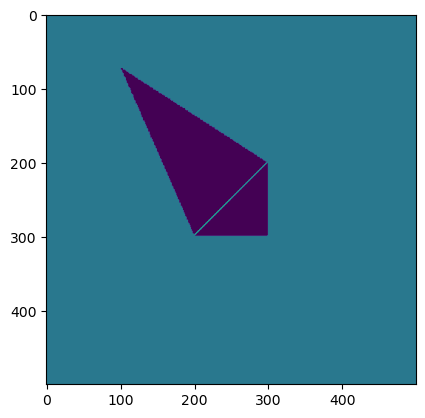

In [212]:
plt.imshow(HS)

In [183]:
sombra[zdiff_i]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

In [154]:
np.roll(zproj, (0,0), (0,1))

array([[ 0.00000000e+00,  2.96198133e-01,  5.92396265e-01, ...,
         1.47210472e+02,  1.47506670e+02,  1.47802868e+02],
       [-1.71010072e-01,  1.25188061e-01,  4.21386194e-01, ...,
         1.47039462e+02,  1.47335660e+02,  1.47631858e+02],
       [-3.42020143e-01, -4.58220106e-02,  2.50376122e-01, ...,
         1.46868452e+02,  1.47164650e+02,  1.47460848e+02],
       ...,
       [-8.49920056e+01, -8.46958075e+01, -8.43996094e+01, ...,
         6.22184663e+01,  6.25146645e+01,  6.28108626e+01],
       [-8.51630157e+01, -8.48668176e+01, -8.45706194e+01, ...,
         6.20474563e+01,  6.23436544e+01,  6.26398525e+01],
       [-8.53340258e+01, -8.50378276e+01, -8.47416295e+01, ...,
         6.18764462e+01,  6.21726443e+01,  6.24688425e+01]])

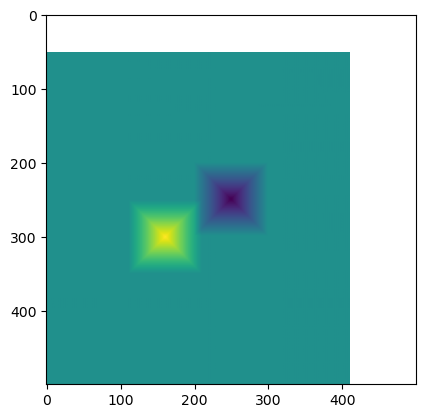

In [166]:

plt.imshow(zdiff)

In [4]:
a = 240
z = 70
sv = Vector(normalvector(np.array([a, z])))
cgrad = cgrad(dem, dlx=1.0)
hsh = hillshading(cgrad, sv.v)
shd = doshade(dem, sv.v, res=1.0)
# compute combined incidence angle and shade factors
HS = hsh * shd

In [119]:
# compute combined incidence angle and shade factors
#HS = hsh * shd
primary = np.array([[40., 1160., 0.],
                    [40., 40., 0.],
                    [260., 40., 0.],
                    [260., 1160., 0.]])

secondary = np.array([[610., 560., 0.],
                      [610., -560., 0.],
                      [390., -560., 0.],
                      [390., 560., 0.]])

# Pad the data with ones, so that our transformation can do translations too
n = primary.shape[0]
pad = lambda x: np.hstack([x, np.ones((x.shape[0], 1))])
unpad = lambda x: x[:,:-1]
X = pad(primary)
Y = pad(secondary)

# Solve the least squares problem X * A = Y
# to find our transformation matrix A
A, res, rank, s = np.linalg.lstsq(X, Y)

transform = lambda x: unpad(np.dot(pad(x), A))


In [69]:
a = 240
z = 70
rows = dem.shape[0]
cols = dem.shape[1]
sv = Vector(normalvector(np.array([a, z])))
inversesunvector = Vector(-sv.v / np.max(np.abs([sv.x, sv.y])))

dims = (int(np.sqrt(cols**2 + rows**2)), int(np.sqrt(cols**2 + rows**2)))
x_coords = np.arange(dims[0])
y_coords = np.arange(dims[1])
X, Y = np.meshgrid(x_coords, y_coords)
coords = np.stack([X.flatten(), Y.flatten()], axis=1)
#coords = np.hstack([coords, np.zeros((coords.shape[0], 1))])
r_coords = coords - (np.array(dims) / 2)
r_coords = r_coords * np.array([inversesunvector.x, inversesunvector.y])
r_coords = r_coords + (np.array(dims) / 2)

In [70]:
mask = ((r_coords >= [0, 0]) & (r_coords < [cols, rows])).all(axis=1)
dsel = r_coords[mask].astype(int)
zarr = dem[dsel[:,1], dsel[:,0]]
r_coords = np.hstack([r_coords, np.zeros((r_coords.shape[0], 1))])
r_coords[:,2][mask] = zarr
zproj = np.dot(r_coords, sv.v)
#zproj[mask].reshape((rows, cols))


In [71]:
out = np.ones(dem.shape)
out[dsel[:,1], dsel[:,0]] = zproj[mask]
out

array([[   1.        ,    1.        ,    1.        , ...,    1.        ,
           1.        ,    1.        ],
       [   1.        ,    1.        ,    1.        , ...,    1.        ,
           1.        ,    1.        ],
       [   1.        ,    1.        ,    1.        , ...,    1.        ,
           1.        ,    1.        ],
       ...,
       [ 233.77151122,  232.95771354,  232.14391586, ..., -170.68593641,
        -171.49973409, -172.31353177],
       [ 234.04277712,  233.22897944,  232.41518175, ..., -170.41467051,
        -171.2284682 , -172.04226588],
       [ 234.5853089 ,  233.77151122,  232.95771354, ..., -169.87213873,
        -170.68593641, -171.49973409]])

In [186]:
a = 240
z = 70
dl = 1.0
theta = np.radians(a)
rows = dem.shape[0]
cols = dem.shape[1]
sv = Vector(normalvector(np.array([a, z])))
inversesunvector = Vector(-sv.v / np.max(np.abs([sv.x, sv.y])))
inv_sp = inv_sun_angles(np.array([a, z]))
normalsunvector = Vector(normalvector(inv_sp))


#dims = (int(np.sqrt(cols**2 + rows**2)), int(np.sqrt(cols**2 + rows**2)))
x_coords = np.arange(cols)
y_coords = np.arange(rows)
X, Y = np.meshgrid(x_coords, y_coords)
coords = np.stack([X.flatten(), Y.flatten()], axis=1)

pad = lambda x: np.hstack([x, np.ones((x.shape[0], 1))])
unpad = lambda x: x[:,:-1]

Affine2DRot = np.array([[np.cos(theta), np.sin(theta), 0],
                        [-np.sin(theta), np.cos(theta), 0],
                        [0, 0, 0]])
A = np.transpose(Affine2DRot)
transform = lambda x: unpad(np.dot(pad(x), A))

coords_T = coords - (np.array(X.shape) / 2)
coords_T = transform(coords_T)
coords_T = coords_T + (np.array(X.shape) / 2)

#coords_xt = coords_T[:,0].reshape(X.shape)
#coords_yt = coords_T[:,1].reshape(Y.shape)

In [187]:
mask = ((coords_T >= [0, 0]) & (coords_T < [cols, rows])).all(axis=1)
dsel = coords_T[mask].astype(int)
zarr = dem[dsel[:,1], dsel[:,0]]
coords_T = coords_T * dl
coords_z = np.empty((coords_T.shape[0], 1))
coords_z[:] = np.nan
coords_T = np.hstack([coords_T, coords_z])
coords_T[:,2][mask] = zarr
zproj = np.dot(coords_T, normalsunvector.v)

In [175]:

sv.y = sv.y*-1


In [176]:
sv.y

np.float64(-0.4698463103929546)

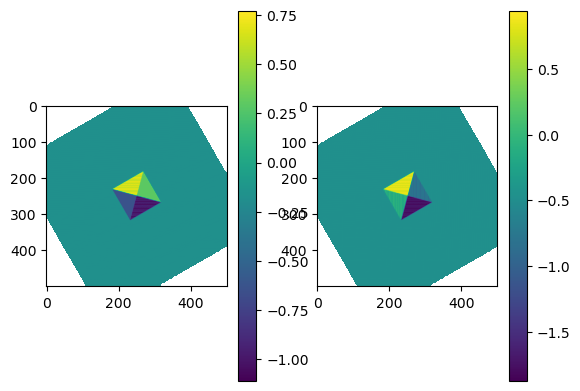

In [191]:
rot_dem = coords_T[:,2].reshape(X.shape)
rot_dem = np.where(rot_dem)
zproj_dem = zproj.reshape(X.shape)
zgrad = np.gradient(zproj_dem)
fig, axs = plt.subplots(nrows=1, ncols=2)
ax1 = axs[0]
ax2 = axs[1]
xim = ax1.imshow(zgrad[0])
fig.colorbar(xim, ax=ax1)
yim = ax2.imshow(zgrad[1] + zgrad[0])
fig.colorbar(yim, ax=ax2)

np.True_

In [242]:
D = dem.values
D2 = D[150:250, 150:250]
out = np.zeros(dem.values.shape)
out[150:250, 150:250] = D2
out

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [226]:
for row in range(out.shape[0]):
    for col in range(out.shape[1]):
        if 0 <= coords_yt[row, col] < dem.shape[0] and 0 <= coords_xt[row, col] < dem.shape[1]:
            out[row, col] = dem[coords_yt[row, col], coords_xt[row, col]]

In [227]:
out

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [158]:
def warpAffine(image, M, output_shape):
    rows, cols = image.shape
    out_rows, out_cols = output_shape

    output = np.zeros(output_shape, dtype=image.dtype)

    for out_row in range(out_rows):
        for out_col in range(out_cols):
            # Calculate the corresponding pixel coordinates in the input image
            in_col, in_row, _ = np.dot(M, [out_col, out_row, 1]).astype(int)

            # Check if the pixel coordinates are within the bounds of the input image
            if 0 <= in_row < rows and 0 <= in_col < cols:
                output[out_row, out_col] = image[in_row, in_col]

    return output

rot_dem = warpAffine(dem, Affine2DRot, (dem.shape[0] + 700, dem.shape[1] + 700))


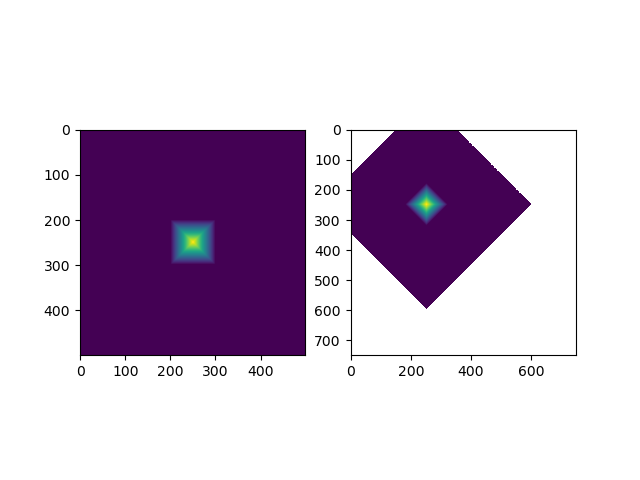

In [228]:
fig4 = plt.figure()
ax5 = fig4.add_subplot(121)
ax6 = fig4.add_subplot(122)
ax5.imshow(dem)
ax6.imshow(out)

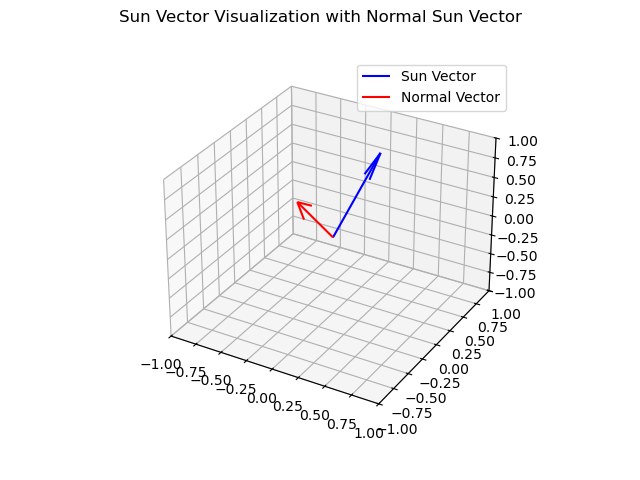

In [98]:
# Visualize sun vector and normal sun vector
sp = sunpos(sv.v)
inv_sp = inv_sun_angles(sp)
nsv = Vector(normalvector(inv_sp))

fig1 = plt.figure()
ax = fig1.add_subplot(111, projection='3d')
ax.quiver([0], [0], [0], [sv.x], [sv.y], [sv.z], color='blue', label='Sun Vector')
ax.quiver([0], [0], [0], [nsv.x], [nsv.y], [nsv.z], color='red', label='Normal Vector')
fig1.suptitle('Sun Vector Visualization with Normal Sun Vector')
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)
ax.legend()


Text(0.5, 0.98, 'Topographic Shading Result')

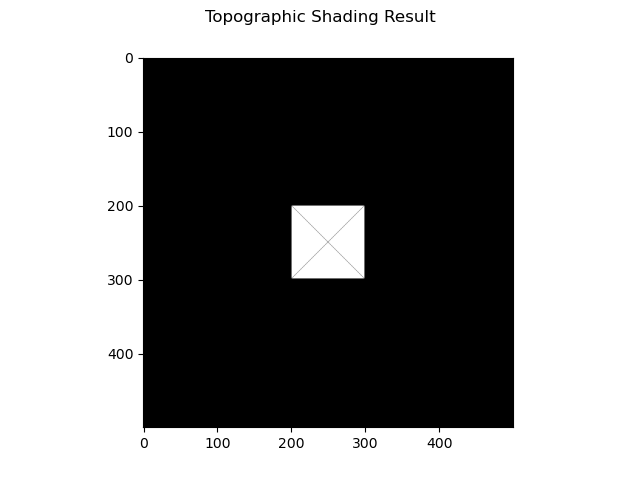

In [101]:
# Visualize hillshading/shade layer
fig2 = plt.figure()
ax2 = fig2.add_subplot(111)
fig2.suptitle('Topographic Shading Result')


In [118]:
ax2.imshow(HS, cmap='gray')

In [213]:
# Get shading/relief for actual topography
# first get some DEM data for a HUC12 cathment
huc12 = '100901010101'
geom = pynhd.WaterData('wbd12').byid('huc12', huc12).geometry[0]
dem = py3dep.get_dem(geom, 30)
dem_proj = dem.rio.reproject(5071)

In [214]:
dem.rio.to_raster('100901010101_30m.tif')

In [225]:
a = 200
z = 58
sv_d = Vector(normalvector(np.array([a, z])))
cgrad_d = cgrad(dem_proj, dlx=dem_proj.rio.resolution()[0])
hsh_d = hillshading(cgrad_d, sv_d.v)
shd_d = new_doshade(dem_proj, sv_d.v, dl=dem_proj.rio.resolution()[0])

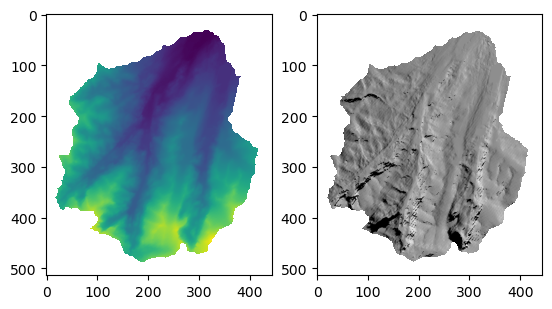

In [226]:
fig3 = plt.figure()
ax3 = fig3.add_subplot(121)
ax4 = fig3.add_subplot(122)
ax3.imshow(dem_proj)
ax4.imshow(hsh_d * shd_d, cmap='gray')

In [217]:
ax3.imshow(dem_proj)
ax4.imshow(hsh_d * shd_d, cmap='gray')

In [42]:
dem = dem
sunvector = np.array([-0.612372, -0.612372, 0.500000])  # from sunvector R function for 2020-01-01
dl = 1.0  #meter
sunvector = Vector(sunvector)
sombra = np.ones(dem.shape)
vectororigin = np.zeros(3)
nrows = dem.shape[0]
ncols = dem.shape[1]

zint = np.zeros(dem.shape)
x_int = np.zeros(dem.shape)
y_int = np.zeros(dem.shape)
zproj = np.zeros(dem.shape)

inversesunvector = Vector(-sunvector.v / np.max(np.abs([sunvector.x, sunvector.y])))

sp = sunpos(sunvector.v)
inv_sp = inv_sun_angles(sp)
normalsunvector = Vector(normalvector(inv_sp))

casx = int(1e6 * sunvector.x)
casy = int(1e6 * sunvector.y)
if casx < 0:
    f_i = 0
else:
    f_i = ncols - 1

if casy < 0:
    f_j = 0
else:
    f_j = nrows - 1

j = f_j
print("Doing columns")
for i in range(ncols):
    n = 0
    zcompare = -1e13
    while n >= 0:
        dx = inversesunvector.x * n
        dy = inversesunvector.y * n
        idx = int(i + dx)
        jdy = int(j + dy)
        if ((idx < 0) | (idx > ncols-1)) | ((jdy < 0) | (jdy > nrows-1)):
            #print("i While break at n={0}".format(n))
            break
        vectororigin[0] = dx * dl
        vectororigin[1] = dy * dl
        vectororigin[2] = dem[jdy, idx]
        zprojection = np.dot(vectororigin, normalsunvector.v)
        x_int[jdy, idx] = vectororigin[0]
        y_int[jdy, idx] = vectororigin[1]
        zint[jdy, idx] = vectororigin[2]
        zproj[jdy, idx] = zprojection
        if zprojection < zcompare:
            sombra[jdy, idx] = 0
        else:
            zcompare = zprojection
        
        n = n + 1

i = f_i
print("Doing rows")
for j in range(nrows):
    n = 0
    zcompare = -1e13
    while n <= (np.sqrt(ncols**2 + nrows**2) + 10 * dl):
        dx = inversesunvector.x * n
        dy = inversesunvector.y * n
        idx = int(i + dx)
        jdy = int(j + dy)
        if ((idx < 0) | (idx > ncols-1)) | ((jdy < 0) | (jdy > nrows-1)):
            #print("j While break at n={0}".format(n))
            break
        vectororigin[0] = dx * dl
        vectororigin[1] = dy * dl
        vectororigin[2] = dem[jdy, idx]
        zprojection = np.dot(vectororigin, normalsunvector.v)
        x_int[jdy, idx] = vectororigin[0]
        y_int[jdy, idx] = vectororigin[1]
        zint[jdy, idx] = vectororigin[2]
        zproj[jdy, idx] = zprojection
        if zprojection < zcompare:
            sombra[jdy, idx] = 0
        else:
            zcompare = zprojection
        
        n = n + 1

np.unique(sombra)

Doing columns
Doing rows


array([0., 1.])

In [38]:
np.dot(np.array([201, 48]), np.array([201, normalsunvector.z]))


np.float64(40434.941114993904)

In [36]:
i

0

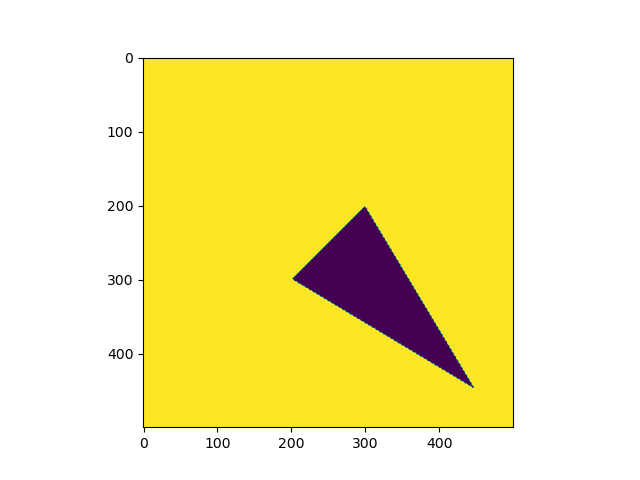

In [41]:
fig2 = plt.figure()
ax2 = fig2.add_subplot(111)

In [73]:
ax2.imshow(ctest[:,:,2])

In [24]:
dem = dem
sunvector = np.array([0.041753, 0.927615, 0.371196])  # from sunvector R function for 2020-01-01
dl = 1.0  #meter
sunvector = Vector(sunvector)
sombra = np.ones(dem.shape)
vectororigin = np.zeros(3)
nrows = dem.shape[0]
ncols = dem.shape[1]

# inversesunvector = -sunvector/Maxval(ABS(sunvector(1:2)))
inversesunvector = -sunvector.v / np.max(np.abs([sunvector.x, sunvector.y]))
normalsunvector = np.zeros(3)
normalsunvector[2] = np.sqrt(sunvector.x**2 + sunvector.y**2)
# normalsunvector(1)=-sunvector(1)*sunvector(3)/normalsunvector(3)
normalsunvector[0] = -sunvector.x * sunvector.z / normalsunvector[2]
normalsunvector[1] = -sunvector.y * sunvector.z / normalsunvector[2]
normalsunvector = Vector(normalsunvector)
# !*** casx is an integer, this makes the value large enough to compare effectively
# casx=NINT(1e6*sunvector(1))        
# casy=NINT(1e6*sunvector(2))
casx = int(1e6 * sunvector.x)
casy = int(1e6 * sunvector.y)
if casx < 0:
    f_i = 0
else:
    f_i = ncols - 1

if casy < 0:
    f_j = 0
else:
    f_j = nrows - 1

j = f_j
print("Doing columns")
for i in range(ncols):
    n = 0
    zcompare = -1e13
    while n <= (np.sqrt(ncols**2 + nrows**2) + 10 * dl):
        dx = inversesunvector[0] * n
        dy = inversesunvector[1] * n
        idx = int(i + dx)
        jdy = int(j + dy)
        if ((idx < 0) | (idx > ncols-1)) | ((jdy < 0) | (jdy > nrows-1)):
            #print("i While break at n={0}".format(n))
            break
        vectororigin[0] = dx * dl
        vectororigin[1] = dy * dl
        vectororigin[2] = dem[jdy, idx]
        zprojection = np.dot(vectororigin, normalsunvector.v) / normalsunvector.mag
        if zprojection < zcompare:
            sombra[jdy, idx] = 0
        else:
            zcompare = zprojection
        
        n = n + 1

i = f_i
print("Doing rows")
for j in range(nrows):
    n = 0
    zcompare = -1e13
    while n <= (np.sqrt(ncols**2 + nrows**2) + 10 * dl):
        dx = inversesunvector[0] * n
        dy = inversesunvector[1] * n
        idx = int(i + dx)
        jdy = int(j + dy)
        if ((idx < 0) | (idx > ncols-1)) | ((jdy < 0) | (jdy > nrows-1)):
            #print("j While break at n={0}".format(n))
            break
        vectororigin[0] = dx * dl
        vectororigin[1] = dy * dl
        vectororigin[2] = dem[jdy, idx]
        zprojection = np.dot(vectororigin, normalsunvector.v) / normalsunvector.mag
        if zprojection < zcompare:
            sombra[jdy, idx] = 0
        else:
            zcompare = zprojection
        
        n = n + 1

np.unique(sombra)

Doing columns
Doing rows


array([0., 1.])

In [18]:
zcompare = -1e13
nd = np.array([1,2,3])
nd.size

3

In [17]:
j = f_j
i = 0
n = 300
#zcompare = -1e13
print(zcompare)
dx = inversesunvector[0] * n
dy = inversesunvector[1] * n
idx = int(i + dx)
jdy = int(j + dy)
#if ((idx < 0) | (idx > ncols-1)) | ((jdy < 0) | (jdy > nrows-1)):
    #print("i While break at n={0}".format(n))
    #break
vectororigin[0] = dx * dl
vectororigin[1] = dy * dl
vectororigin[2] = dem[jdy, idx]
zprojection = np.dot(vectororigin, normalsunvector)
print(zprojection)
if zprojection < zcompare:
    sombra[jdy, idx] = 0
else:
    zcompare = zprojection

print(idx)
print(jdy)
print(zcompare)
print(zprojection)
print(vectororigin)
print(normalsunvector)

107.75583117430806
111.47154949066352
-13
199
111.47154949066352
111.47154949066352
[ -13.50333921 -300.            0.        ]
[-0.01669105 -0.37082055  0.9285542 ]


In [123]:
def roll2d_with_nans(arr, shift):
    rarr = np.roll(arr, shift, axis=(0,1))
    if shift[0] > 0:
        rarr[:shift[0],:] = np.nan
    elif shift[0] < 0:
        rarr[shift[0]:,:] = np.nan
    else:
        pass

    if shift[1] > 0:
        rarr[:,:shift[1]] = np.nan
    elif shift[1] < 0:
        rarr[:,shift[1]:] = np.nan
    else:
        pass
    
    return rarr

In [128]:
tarr = np.array([[1,2,3,4],
                 [3,4,5,6],
                 [6,7,8,9],
                 [4,5,6,7]], dtype=float)
r = np.roll(tarr, (-1,-1), axis=(0,1))
roll2d_with_nans(tarr, (-1,-1))


array([[ 4.,  5.,  6., nan],
       [ 7.,  8.,  9., nan],
       [ 5.,  6.,  7., nan],
       [nan, nan, nan, nan]])

In [175]:
vectororigin * normalsunvector

array([174.1682703 , 174.1682703 ,  11.38805653])

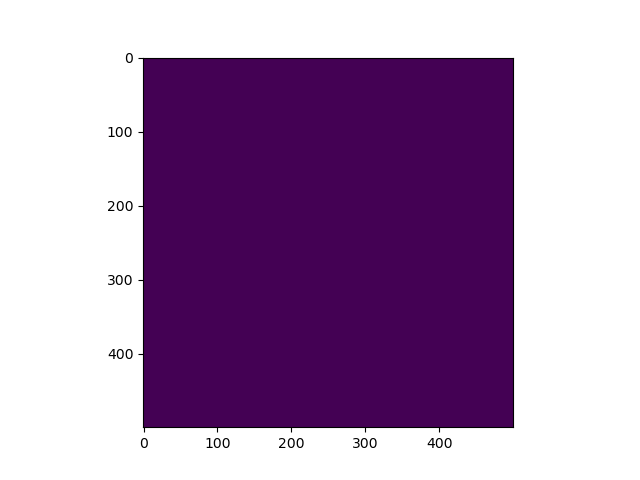

In [87]:
fig2 = plt.figure()
ax2 = fig2.add_subplot(111)
ax2.imshow(sombra)


In [ ]:
ax = plt.axes()
ax.imshow(dem)

In [2]:
## Experiment with a 1D doshade function
##  this calculates if a single point/cell is shaded only
##  can batch by looping over multiple points

lakes = gpd.read_file(r'D:\ArcGIS_Projects\Yellowstone\Tongue River\Vector\HWWY_reservoirs.shp')
basin = gpd.read_file(r'D:\ArcGIS_Projects\Yellowstone\Tongue River\Vector\Tongue_Boundary_Albers.shp')
dem_geom = basin.to_crs(4326).geometry[0]
dem = py3dep.get_dem(dem_geom, 30)

In [3]:
dem

<xarray.DataArray 'elevation' (y: 7096, x: 8451)> Size: 240MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 68kB -107.8 -107.8 -107.8 ... -105.4 -105.4 -105.4
  * y            (y) float64 57kB 46.41 46.41 46.41 46.41 ... 44.44 44.44 44.44
    spatial_ref  int64 8B 0
Attributes:
    scale_factor:         1.0
    add_offset:           0.0
    _FillValue:           nan
    units:                m
    vertical_datum:       NAVD88
    vertical_resolution:  0.001

In [4]:
dem = dem.rio.reproject(5071)

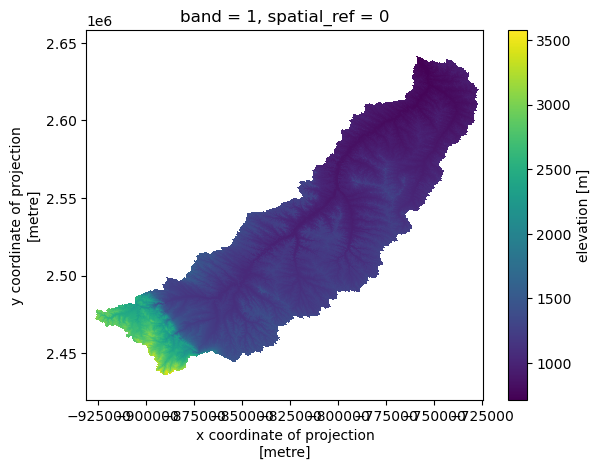

In [6]:
dem.plot()

In [230]:
# Test time for new_doshade on large dem
a = 200
z = 58
sv_d = Vector(normalvector(np.array([a, z])))
cgrad_d = cgrad(dem, dlx=dem.rio.resolution()[0])
hsh_d = hillshading(cgrad_d, sv_d.v)
shd_d = new_doshade(dem, sv_d.v, dl=dem.rio.resolution()[0])

KeyboardInterrupt: 

In [ ]:
fig4 = plt.figure()
ax1 = fig4.add_subplot(121)
ax2 = fig4.add_subplot(122)
ax1.imshow(dem)
ax2.imshow(hsh_d * shd_d, cmap='gray')

In [5]:
dem.rio.to_raster('Tongue_R_30m.tif')

In [159]:
sv = normalvector(np.array([230, 85]))
sv

array([-0.76312941,  0.64034161,  0.08715574])

In [70]:
x = sv[0]
y = sv[1]
z = sv[2]
nrows, ncols = dem.data.shape
rsltn = dem.rio.resolution()[0]
ray_ln = np.max(dem.data.shape)
d = np.sqrt(np.sqrt(1)/(x**2 + y**2))
dr = np.arange(0, ray_ln, d)
xr = (dr * x).astype(int)
yr = (dr * y).astype(int)
zr = dr * rsltn * z

In [232]:
affn = dem.rio.transform()
lakes = lakes.to_crs(5071)
tlake = lakes.geometry[0]
tpnt = tlake.centroid
origin = rio.transform.rowcol(affn, tpnt.x, tpnt.y)

In [72]:
zorigin = dem.data[origin[0], origin[1]]
xis = xr + origin[1]
yjs = yr + origin[0]
zproj = zr + zorigin
lnmsk = np.where(((xis > 0) & (xis < ncols-1)) & ((yjs > 0) & (yjs < nrows-1)))
xi_clp = xis[lnmsk[0]]
yj_clp = yjs[lnmsk[0]]
z_ext = dem.data[yj_clp, xi_clp]
z_extnan = z_ext[~np.isnan(z_ext)]

In [9]:
r = zproj[lnmsk[0]] - z_ext
(r < 0).any()

np.False_

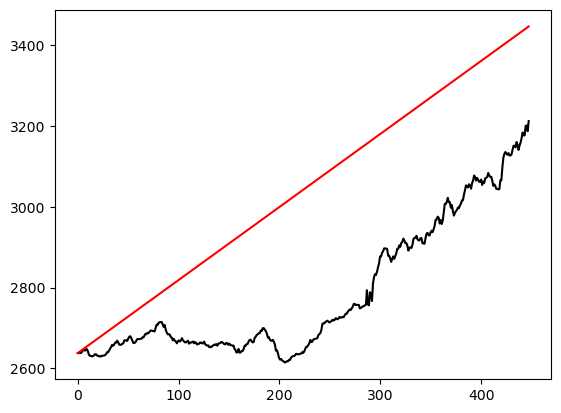

In [73]:
plt.plot(dr[np.where(~np.isnan(z_ext))], z_extnan, 'k-')
plt.plot(dr[np.where(~np.isnan(z_ext))], zproj[np.where(~np.isnan(z_ext))], 'r-')

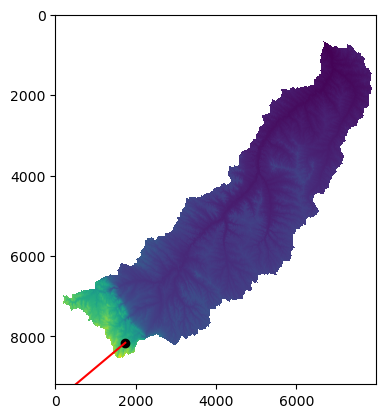

In [41]:
plt.imshow(dem.data)
plt.plot(origin[1], origin[0], 'ko')
plt.plot(xi_clp, yj_clp, 'r-')

In [6]:
geom = lakes[lakes['Permanent_'] == '71772129']
shd = doshade_geometry(dem, geom.centroid, sv, rsltn, affn)
hs = hillshade_geometry(dem, geom.centroid, sv, rsltn, affn)
print(shd)
print(hs)
print(shd * hs)

C:\Users\CNB968\AppData\Local\Temp\ipykernel_25364\3236705399.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  shd = doshade_geometry(dem, geom.centroid, sv, rsltn, affn)


NameError: name 'sv' is not defined

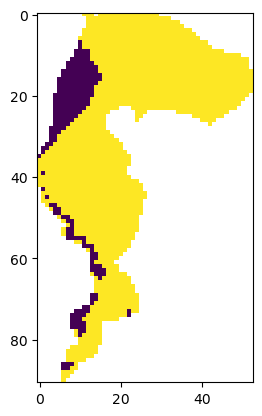

In [161]:
shdpoly = doshade_geometry(dem, geom, sv, rsltn, affn, poly_output='raster')
hspoly = hillshade_geometry(dem, geom, sv, rsltn, affn, poly_output='raster')
HS = shdpoly * hspoly
plt.imshow(shdpoly.data)

In [154]:
shdpoly.min()

<xarray.DataArray 'shade_factor' ()> Size: 4B
array(0., dtype=float32)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0

In [155]:
print(doshade_geometry(dem, geom, sv, rsltn, affn, poly_output='scalar'))
print(hillshade_geometry(dem, geom, sv, rsltn, affn, poly_output='scalar'))

0.9888712241653418
0.13814470597550146


In [238]:
dem

<xarray.DataArray 'elevation' (y: 9192, x: 7986)> Size: 294MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * x            (x) float64 64kB -9.313e+05 -9.312e+05 ... -7.244e+05
  * y            (y) float64 74kB 2.658e+06 2.658e+06 ... 2.42e+06 2.42e+06
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    scale_factor:         1.0
    add_offset:           0.0
    units:                m
    vertical_datum:       NAVD88
    vertical_resolution:  0.001
    _FillValue:           nan

In [244]:
geom = lakes[lakes['Permanent_'] == '71772129']
geom_p = geom.centroid
sv = normalvector(np.array([230, 85]))
svaz = np.random.randint(0, 360, 4000)
svz = np.random.randint(1, 89, 4000)

out = []
for i in np.arange(svaz.size):
    sv = normalvector(np.array([svaz[i], svz[i]]))
    r = doshade_geometry(dem, geom, sv)
    out.append(r)

KeyboardInterrupt: 

In [14]:
from datetime import datetime, timedelta

geom = lakes[lakes['Permanent_'] == '71772129']
geom_p = geom.centroid
sv = normalvector(np.array([230, 85]))
svaz = np.random.randint(0, 360, 4000)
svz = np.random.randint(1, 89, 4000)
raster = dem
timezone = -7

clipped = raster.rio.clip(geom.geometry.values, geom.crs, drop=False)
origins = np.where(~np.isnan(clipped.data))
zorigins = datarray[origins[0], origins[1]]
xos = origins[1][None, :]
yos = origins[0][None, :]

datarray = raster.data
data_res = raster.rio.resolution()[0]

out = []
for i in np.arange(svaz.size):
    sv = normalvector(np.array([svaz[i], svz[i]]))

    xv = sv[0]
    yv = sv[1]
    zv = sv[2]
    nrows, ncols = datarray.shape
    ray_ln = np.max(datarray.shape)
    d = np.sqrt(np.sqrt(1) / (xv ** 2 + yv ** 2))
    dr = np.arange(0, ray_ln, d)
    xr = (dr * xv).astype(int)
    yr = (dr * yv).astype(int)
    zr = dr * data_res * zv

    xros = np.tile(xr, (origins[1].shape[0], 1)).T  # depends on sv
    xis = (xos + xros)
    yros = np.tile(yr, (origins[1].shape[0], 1)).T  # depends on sv
    yjs = (yos + yros)
    xboo = ((xis > 0) & (xis < ncols - 1)).all(axis=1)
    xmsk_sz = xboo[xboo].shape[0]
    xboo = np.tile(xboo, (xis.shape[1], 1)).T
    yboo = ((yjs > 0) & (yjs < nrows - 1)).all(axis=1)
    ymsk_sz = yboo[yboo].shape[0]
    yboo = np.tile(yboo, (yjs.shape[1], 1)).T
    lnmsk = np.logical_and(xboo, yboo)
    msk_rows = np.min([xmsk_sz, ymsk_sz])
    msk_cols = lnmsk.shape[1]
    xi_clp = xis[lnmsk]
    yj_clp = yjs[lnmsk]
    z_ext = datarray[yj_clp, xi_clp]
    z_ext = z_ext.reshape((msk_rows, msk_cols))
    zproj = zorigins[None, :] + np.tile(zr, (zorigins.shape[0], 1)).T
    zdiff = zproj[lnmsk].reshape((msk_rows, msk_cols)) - z_ext
    shdf = np.where((zdiff < 0).any(axis=0), 0.0, 1.0)
    shd = np.nanmean(shdf)

    hsh = hillshade_geometry(raster, geom, sv, poly_output='scalar')
    HS = hsh * shd

    out.append(HS)


C:\Users\CNB968\AppData\Local\Temp\ipykernel_26676\571177973.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geom_p = geom.centroid


KeyboardInterrupt: 

In [13]:
datarray = raster.data

In [243]:
np.where(np.array(out) == 0)

(array([ 140,  169,  349,  392,  431,  483,  485,  520,  536,  608,  657,
         658,  698,  775,  889,  911,  926,  936,  944, 1170, 1244, 1303,
        1332, 1338, 1385, 1422, 1497, 1549, 1634, 1684, 1799, 1841, 1851,
        1916, 1981, 2000, 2042, 2286, 2401, 2414, 2454, 2503, 2511, 2551,
        2639, 2668, 2671, 2677, 2827, 2864, 2908, 2952, 2982, 3076, 3086,
        3125, 3203, 3218, 3278, 3297, 3533, 3554, 3594, 3625, 3672, 3698,
        3714, 3729, 3792, 3837, 3922, 3936, 3963]),)

In [7]:
lakes

,Permanent_,FDate,Resolution,GNIS_ID,GNIS_Name,AreaSqKm,Elevation,ReachCode,FType,FCode,Visibility,Shape_Leng,Shape_Area,NHDPlusID,VPUID,geometry
0,71772797,2003-02-20,2,01600849,Last Chance Reservoir,0.051000,0.0000,10090101001988,390,39004,0,0.010722,0.000006,2.300250e+13,1009,"POLYGON Z ((-107.20212 44.54075 0, -107.20222 ..."
1,71772129,2016-11-03,2,01606753,Colorado Colony Ditch Company Reservoir Number 2,1.257994,0.0000,10090101001985,390,39004,0,0.080258,0.000142,2.300250e+13,1009,"POLYGON Z ((-107.21701 44.54794 0, -107.21706 ..."
2,71759682,2003-02-20,2,01606767,Dome Lake Number 1,0.204000,0.0000,10090101001957,390,39004,0,0.022006,0.000023,2.300250e+13,1009,"POLYGON Z ((-107.31638 44.60378 0, -107.3165 4..."
3,71772927,2003-02-20,2,01608139,Willits Reservoir,0.026000,0.0000,10090101001989,390,39004,0,0.007028,0.000003,2.300250e+13,1009,"POLYGON Z ((-107.19553 44.53306 0, -107.19524 ..."
4,71759808,2003-02-20,2,01587705,Dome Lake Reservoir,0.357000,0.0000,10090101001969,390,39004,0,0.031711,0.000040,2.300250e+13,1009,"POLYGON Z ((-107.30002 44.58734 0, -107.30028 ..."
5,71818121,2003-02-20,2,01604632,Sawmill Reservoir,0.265000,0.0000,10090101001947,390,39004,0,0.030454,0.000030,2.300250e+13,1009,"POLYGON Z ((-107.30802 44.62497 0, -107.30803 ..."
6,71759956,2003-02-20,2,01596266,Weston Reservoir,0.138000,0.0000,10090101001976,390,39004,0,0.019932,0.000016,2.300250e+13,1009,"POLYGON Z ((-107.26949 44.56848 0, -107.26951 ..."
7,120031076,2012-11-26,2,01599036,Cross Creek Reservoir,0.223523,2745.6384,10090101001994,390,39009,0,0.022913,0.000025,2.300250e+13,1009,"POLYGON Z ((-107.20592 44.50409 0, -107.20575 ..."
8,71772901,2016-11-03,2,01606391,Big Horn Reservoir,0.669102,0.0000,10090101001993,390,39004,0,0.042110,0.000076,2.300250e+13,1009,"POLYGON Z ((-107.20568 44.52121 0, -107.20608 ..."
9,71772619,2003-02-20,2,01601274,Martin Reservoir,0.120000,0.0000,10090101001987,390,39004,0,0.021942,0.000014,2.300250e+13,1009,"POLYGON Z ((-107.20057 44.54992 0, -107.20015 ..."


In [15]:
geom = lakes[lakes['Permanent_'] == '71772129']
datarray = dem.data
#lkpnt = lk.centroid
#lkpnt.geom_type
geom.geometry.values
dem.data

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)

In [9]:

if geom.geometry.geom_type[0] == 'Point':
    origin = rio.transform.rowcol(affn, tpnt.x, tpnt.y)
elif geom.geometry.geom_type[0] == 'Polygon':
    clipped = dem.rio.clip(geom.geometry.values, geom.crs, drop=False)
else:
    print("Geometry type given is not compatible.")
# for polygon, clip, get indices, combine into 1 index array, use numpy.take() to select on axis=1
#  then use differenct zproj - z_ext arrays, use numpy.where(numpy.any(axis=1), 0, 1)
#  will need to adjust length of all rays to the shortest length too
origins = np.where(~np.isnan(clipped))
zorigins = datarray[origins[0], origins[1]]
xos = origins[1][None, :]
yos = origins[0][None, :]
xros = np.tile(xr, (origins[1].shape[0], 1)).T
xis = (xos + xros)
yros = np.tile(yr, (origins[1].shape[0], 1)).T
yjs = (yos + yros)
xboo = ((xis > 0) & (xis < ncols-1)).all(axis=1)
xmsk_sz = xboo[xboo].shape[0]
xboo = np.tile(xboo, (xis.shape[1], 1)).T
yboo = ((yjs > 0) & (yjs < nrows-1)).all(axis=1)
ymsk_sz = yboo[yboo].shape[0]
yboo = np.tile(yboo, (yjs.shape[1], 1)).T
lnmsk = np.logical_and(xboo, yboo)
msk_rows = np.min([xmsk_sz, ymsk_sz])
msk_cols = lnmsk.shape[1]
xi_clp = xis[lnmsk]
yj_clp = yjs[lnmsk]
z_ext = datarray[yj_clp, xi_clp]
z_ext = z_ext.reshape((msk_rows, msk_cols))
zproj = zorigins[None, :] + np.tile(zr, (zorigins.shape[0], 1)).T
zdiff = zproj[lnmsk].reshape((msk_rows, msk_cols)) - z_ext
shd = np.where((zdiff < 0).any(axis=0), 0.0, 1.0)
## incorporate in above functions section for geometry type polygon
##  have an additional kwarg for return type - scalar or array(maybe rioxarray dataset?)

In [79]:
cd = dem.rio.clip(geom.geometry.values, geom.crs)
garr = cgrad(cd.data, rsltn)
HS = hillshading(garr, sv)
HS

array([[       nan,        nan, 0.08565498,        nan,        nan,
               nan, 0.08186795, 0.07548336,        nan,        nan],
       [       nan, 0.05121453, 0.06803903, 0.0941931 ,        nan,
        0.09226385, 0.08198909, 0.0774448 ,        nan,        nan],
       [       nan,        nan, 0.06738454, 0.07087617, 0.07181574,
        0.07081857, 0.06981228, 0.06983929, 0.06989272,        nan],
       [       nan,        nan, 0.06186696, 0.06975647, 0.06975647,
        0.06975647, 0.06975647, 0.06975647, 0.06988372, 0.06121071],
       [       nan,        nan, 0.05603   , 0.06969605, 0.06975647,
        0.06975647, 0.06975647, 0.06975532, 0.0705216 ,        nan],
       [       nan,        nan, 0.04432276, 0.06975496, 0.06975647,
        0.06974567, 0.06933764, 0.06790399,        nan,        nan],
       [       nan,        nan, 0.03127199, 0.06898601, 0.06976374,
        0.06964128, 0.06304433,        nan,        nan,        nan],
       [       nan,        nan,        na

In [74]:
xos = origins[1][None, :]
yos = origins[0][None, :]
xros = np.tile(xr, (origins[1].shape[0], 1)).T
xis = (xos + xros)
#xis = np.clip(xis, 0, ncols-1)
yros = np.tile(yr, (origins[1].shape[0], 1)).T
yjs = (yos + yros)
#yjs = np.clip(yjs, 0, nrows-1)
#idarr = np.column_stack([xris, yris])
#z_ext = datarray[yjs.flatten(), xis.flatten()]
#z_ext = z_ext.reshape(xis.shape)
yjs.shape

(7796, 76)

In [97]:
xboo = ((xis > 0) & (xis < ncols-1)).all(axis=1)
xmsk_sz = xboo[xboo].shape[0]
xboo = np.tile(xboo, (xis.shape[1], 1)).T
yboo = ((yjs > 0) & (yjs < nrows-1)).all(axis=1)
ymsk_sz = yboo[yboo].shape[0]
yboo = np.tile(yboo, (yjs.shape[1], 1)).T
lnmsk = np.logical_and(xboo, yboo)
msk_rows = np.min([xmsk_sz, ymsk_sz])
msk_cols = lnmsk.shape[1]
xi_clp = xis[lnmsk]
yj_clp = yjs[lnmsk]
z_ext = datarray[yj_clp, xi_clp]
z_ext = z_ext.reshape((msk_rows, msk_cols))
zproj = zorigins[None, :] + np.tile(zr, (zorigins.shape[0], 1)).T
zdiff = zproj[lnmsk].reshape((msk_rows, msk_cols)) - z_ext
shd = np.where((zdiff < 0).any(axis=0), 0.0, 1.0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1.])

In [24]:
clipped.data[origins[0], origins[1]] = shd
shd = clipped.rename('shade_factor')
shd.attrs = {'units': '1=not shaded, 0=shaded'}
shd = shd[np.min(origins[0]):np.max(origins[0]+1), np.min(origins[1]):np.max(origins[1]+1)]
shd

<xarray.DataArray 'shade_factor' (y: 13, x: 10)> Size: 520B
array([[nan,  1.,  1.,  1., nan,  1.,  1.,  1.,  1., nan],
       [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., nan],
       [nan,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [nan,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [nan,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
       [nan,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., nan],
       [nan,  1.,  1.,  1.,  1.,  1.,  1.,  1., nan, nan],
       [nan, nan,  1.,  1.,  1.,  1.,  1., nan, nan, nan],
       [nan, nan,  1.,  1.,  1., nan, nan, nan, nan, nan],
       [nan, nan,  1.,  1.,  1., nan, nan, nan, nan, nan],
       [nan, nan, nan,  1.,  1.,  1., nan, nan, nan, nan],
       [nan, nan, nan,  1.,  1.,  1., nan, nan, nan, nan],
       [nan, nan, nan, nan,  1., nan, nan, nan, nan, nan]], dtype=float32)
Coordinates:
  * x            (x) float64 80B -8.863e+05 -8.862e+05 ... -8.86e+05 -8.86e+05
  * y            (y) float64 104B 2.447e+06 2.447e+06 ... 2.447e+06 2.447e+06
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    units:    1=not shaded, 0=shaded